<a href="https://colab.research.google.com/github/BelenUrdangarin/Entregables---Urdangarin/blob/main/Notebook_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa Ingenias+ Data Science

En esta notebook, vamos a demostrar como funcionan los algoritmos vistos en clase y su implementación en Scikit-learn.

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
data, target = load_iris(return_X_y=True, as_frame=True)

#return_X_y=True, Este parametro le dice a la función que devuelva los features y las etiquetas de forma separada en dos variables
#as_frame=True, Este parametro se asegura de que la data y la etiqueta se presenten como un dataframe de panda
#El dataset iris es muy utilizado para machine learning y contiene las medidas de 150 flores con
#50 muestras por cada tipo de flor

In [3]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
target.head()

,target
0,0
1,0
2,0
3,0
4,0


In [5]:
X = np.array(data) #convertimos la data en arrays
y = np.array(target)

In [6]:
feature_names = data.columns

# Random Forest

[Documentacion](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn-ensemble-randomforestclassifier)

In [7]:
from sklearn.ensemble import RandomForestClassifier
#Algoritmo de aprendizaje que utiliza arboles de decisión para hacer predicciones. estos dividen los datos
#en función de las caracteristicas relevantes para llegar a una predicción.

In [8]:
rf = RandomForestClassifier(n_estimators=200, criterion='entropy', max_features='sqrt')
#n_estimators, especifica el numero de arboles de decisión para contruir el forest. A mayor cantidad de estimadores, mejor es el resultado
#criterion='entropy', determina la función que mide la calidad de la separación en cada arbol de decisión
#Entropia se refiere a el criterio de ganancia de información. este criterio mide la impureza de las muestras
#max_features='sqrt', controla el numero de features a considerar cuando se busca la mejor separación
#en cada nodo del arbol de decisón, cuando se utiliza el ¨sqrt¨, el numero de features considerados
#en cada division será la raiz cuadrada del numero total de features en el dataset. esto ayuda a reducir
#la correlación de los arboles en el forest, lo que mejora la robustez del modelo


In [9]:
rf.fit(X, y) #Entrenamos el modelo

RandomForestClassifier(criterion='entropy', n_estimators=200)

In [10]:
estimator = rf.estimators_[5] #es una lista que contiene cada arbol de decisión individual
#Cada elemento en la lista es una instancia del arbol de decisión

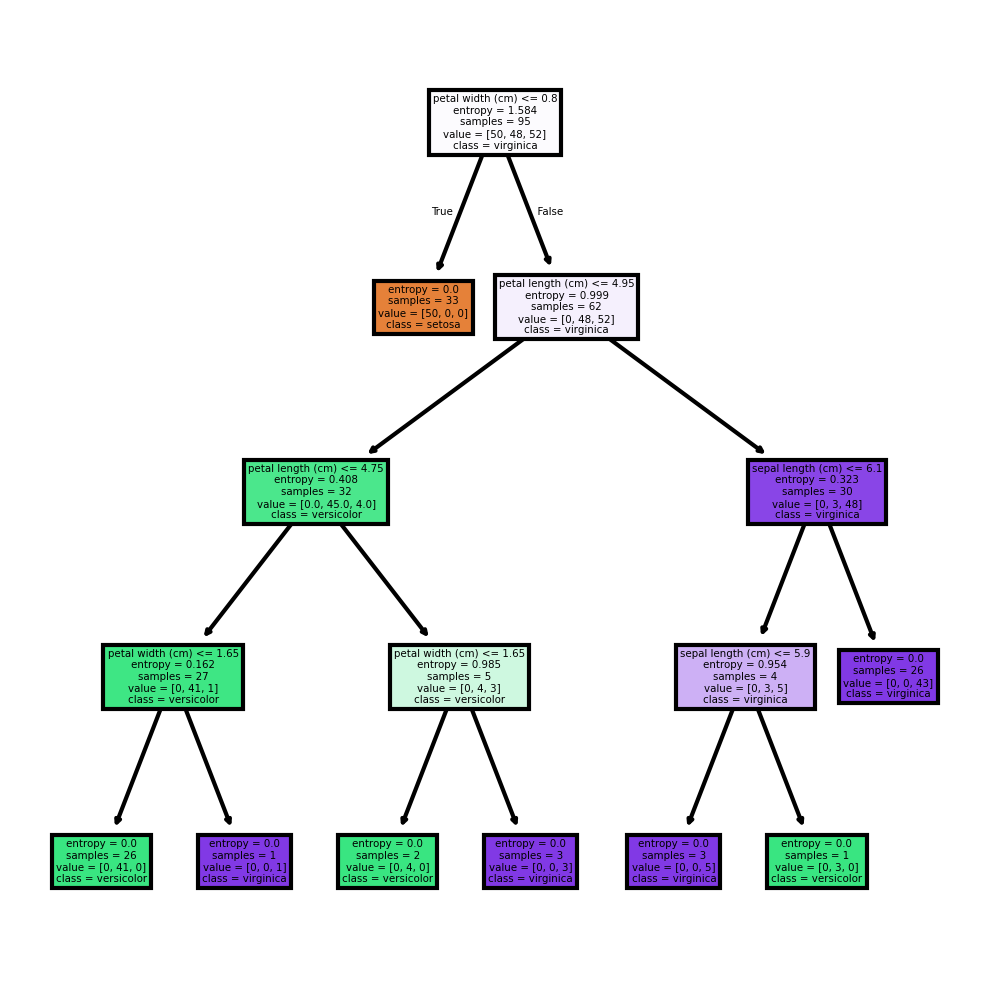

In [11]:
#Este codigo se utilizara para visualizar un arbol de decisión que conforma el random forest
from sklearn.tree import plot_tree

fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (4,4), dpi=300)
#El numero de filas y columnas indican que queremos un solo plot y dpi la cantidad de puntos por pulgada

plot_tree(rf[0], #selecciona el primer arbol de decision, rf.estimators contiene cada arbol individual
          feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)'], #Provee la lista de nombres para los campos que seran mostrados en los nodos de decision para indicar que campo se usa para la division
          class_names=['setosa', 'versicolor', 'virginica'], #provee una lista de nombres que aparecen en las hojas del arbol que indica la marca predicha
          filled = True); #Colorea el nodo


En el contexto del arbol de decision, la entropia es el concepto prestado de la teoria de la informacion. Se utiliza para medir la impureza o desorden de la data. Cuando se arma un arbol de decision, la meta es hacer divisiones para reducir la impureza en los resultados, la entropia ayuda a cuantificar la impureza.
 - Si toda la data in la coleccion pertenece a la misma clase, el conjunto es considerado puro. No hay incertidumbre sobre la clase, la entropia se encuentra en su valor minimo (cero).
 - Si la data se encuentra mezclada y pertenece a diferentes clases, el set se considera impuro. Hay cierta incertidumbre sobre la clase de la data seleccionada de forma random para este set. cuantas mas mezclas de case se encuentren, mas alta es la impureza y su entropia. La entropia se encuentra en su maximo valor.

 Cuando se selecciona la division de nodos en base a la entropia, el algoritmo considera diferentes formas de dividir la data en base al campo y elige la division que resulta en la mayor disminucion de entropia. Una alta disminucion de entropia significa que la division

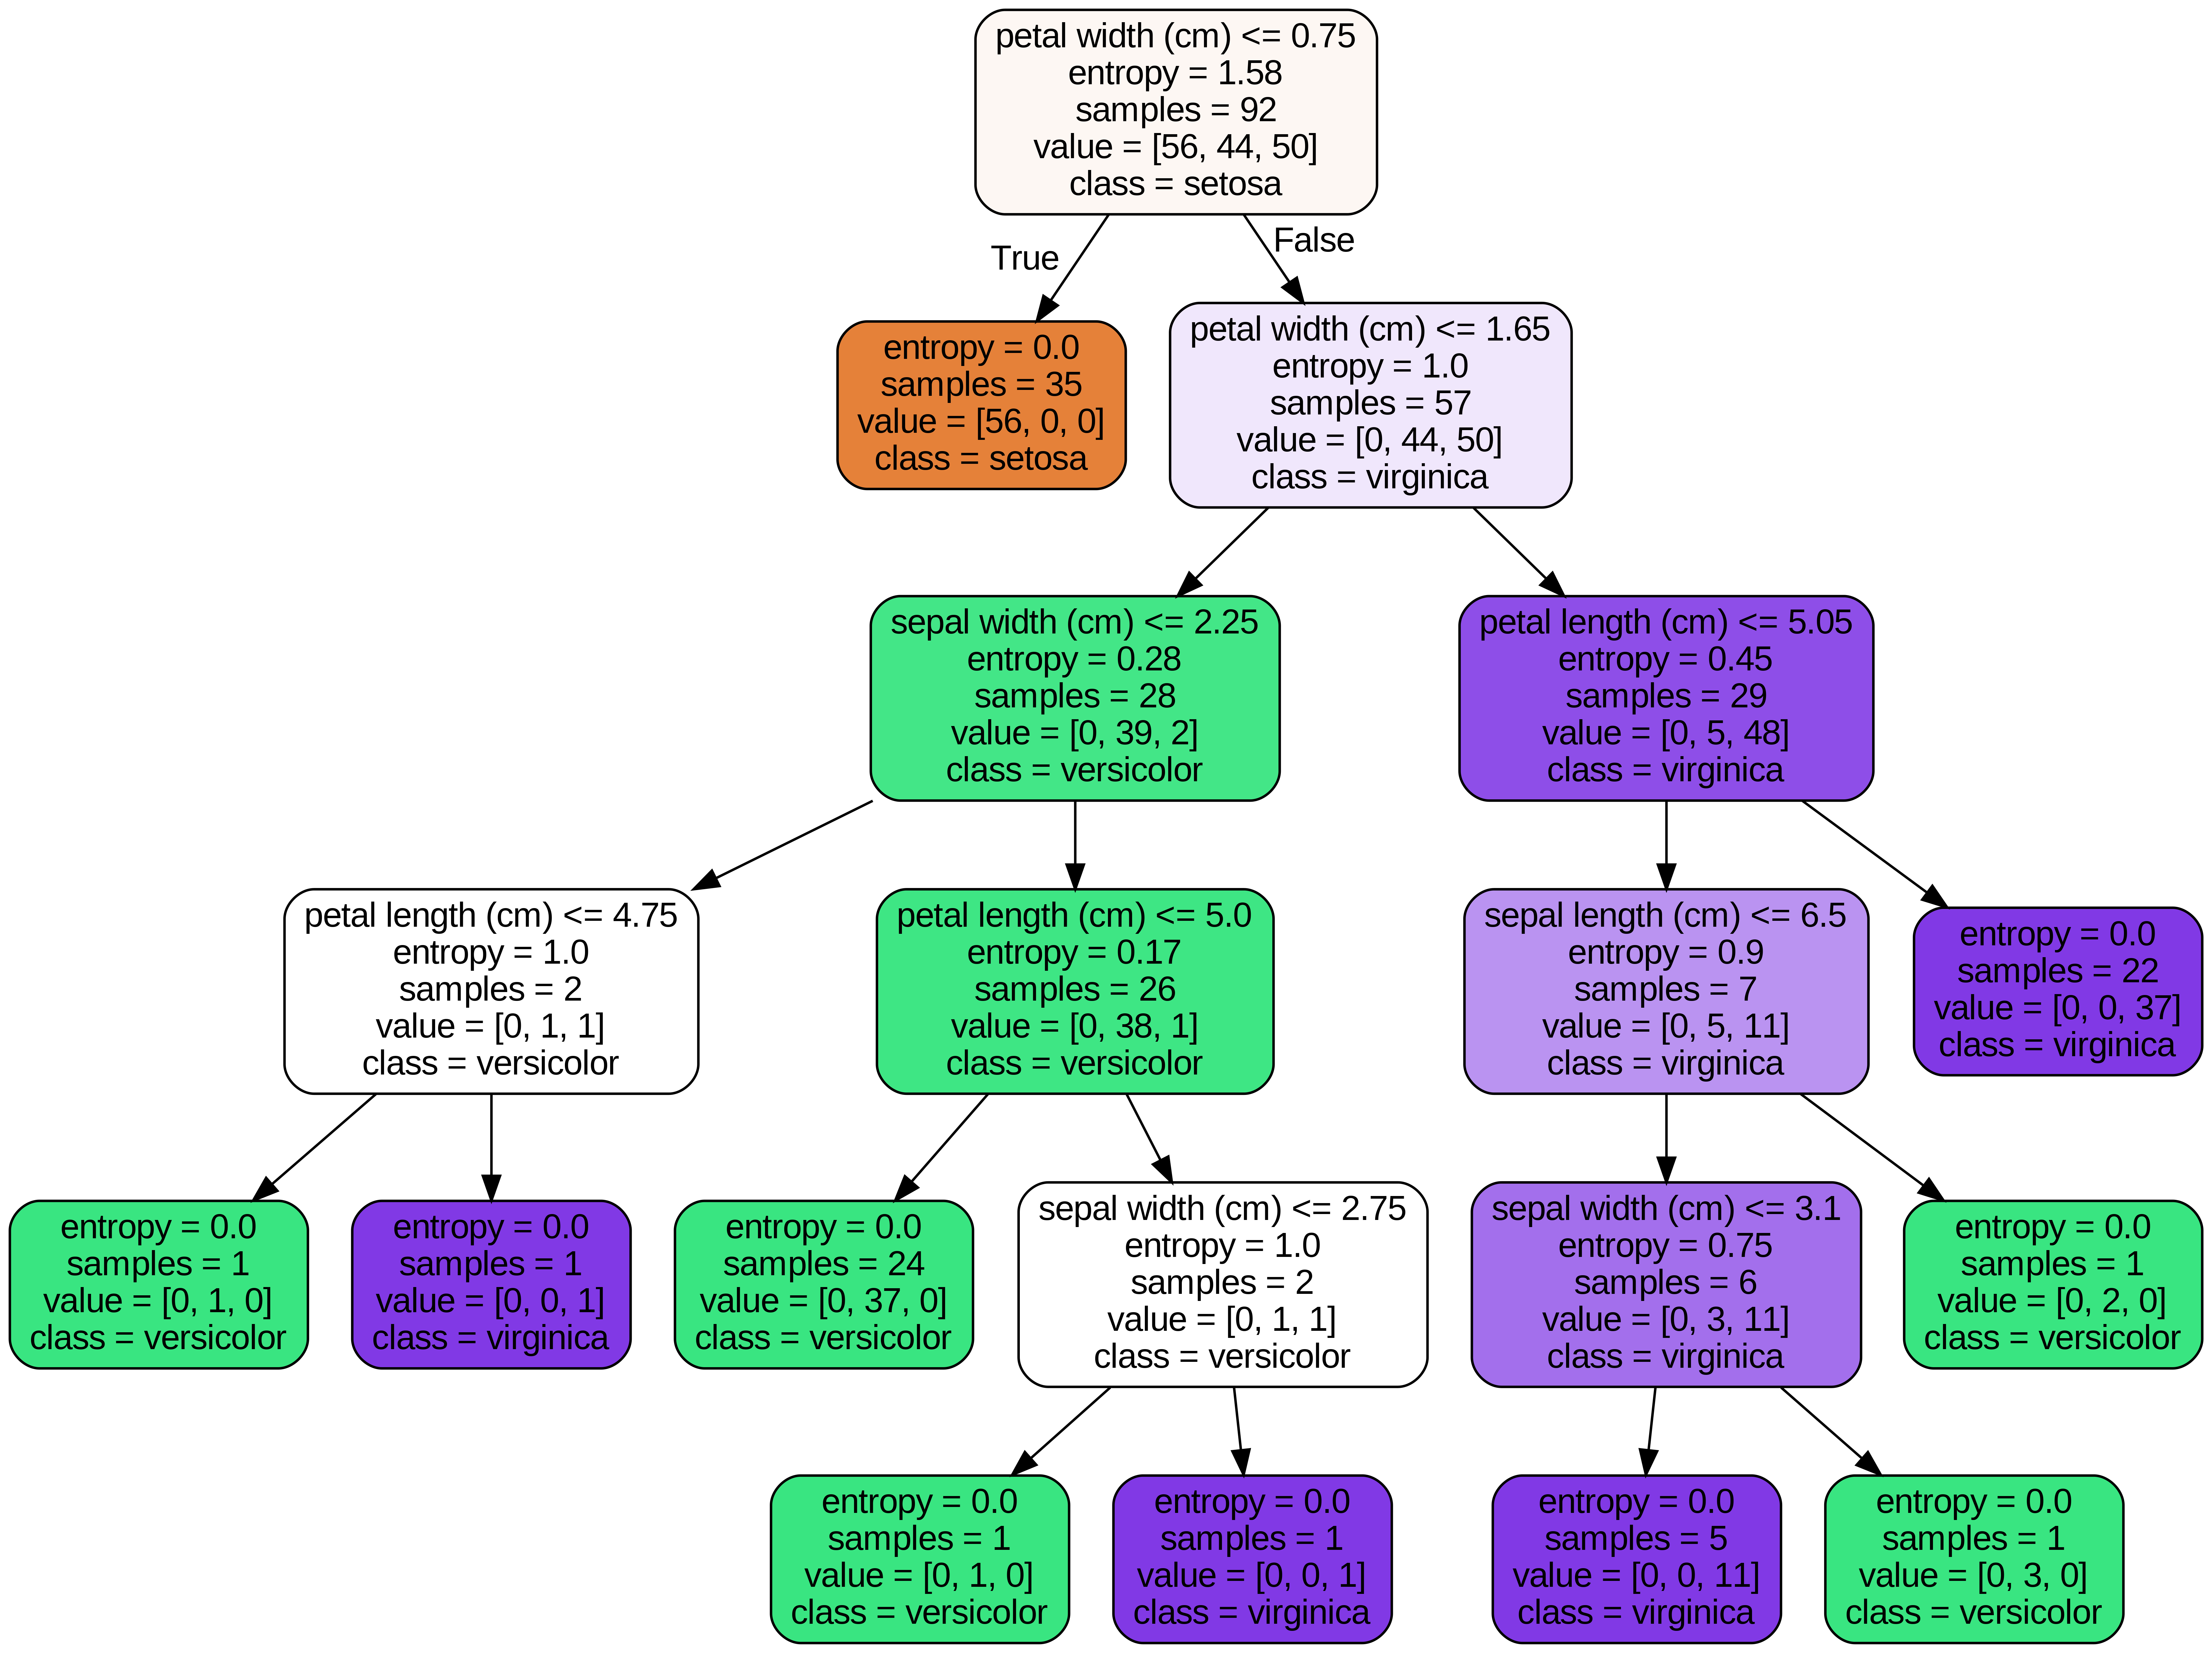

In [ ]:
#Es otra forma de exportar un arbol de decision en el formato .dot que es un formato basado en texto para describir graficos
from sklearn.tree import export_graphviz

#
export_graphviz(estimator, out_file='tree.dot',
                feature_names = iris.feature_names,
                class_names = iris.target_names,
                rounded = True, proportion = False,
                precision = 2, filled = True)

from subprocess import call
call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

from IPython.display import Image
Image(filename = 'tree.png')

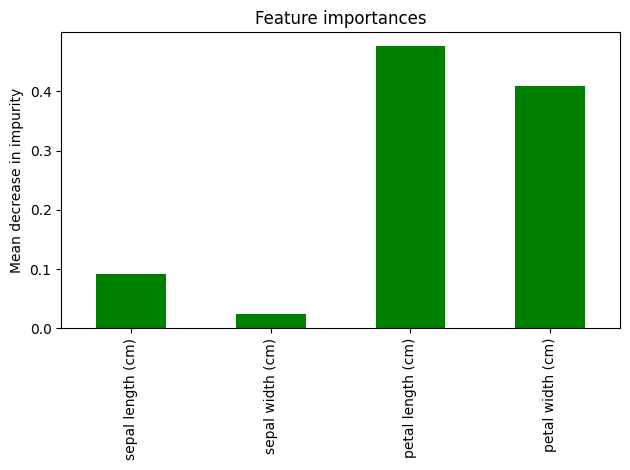

In [ ]:
importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax, color='green')
ax.set_title("Feature importances")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

# Support Vector Machine

In [ ]:
from sklearn.svm import SVC, LinearSVC

In [ ]:
X_ir = data.iloc[: ,[0, 2]]

In [ ]:
sup_vector = SVC()

In [ ]:
sup_vector.fit(X_ir, y)

SVC()

In [ ]:
sup_vector.support_vectors_

array([[4.3, 1.1],
       [5.7, 1.7],
       [5.1, 1.7],
       [4.8, 1.9],
       [5.1, 1.9],
       [7. , 4.7],
       [6.9, 4.9],
       [6.5, 4.6],
       [5.7, 4.5],
       [6.3, 4.7],
       [4.9, 3.3],
       [6.6, 4.6],
       [6.1, 4.7],
       [5.6, 4.5],
       [6.2, 4.5],
       [5.9, 4.8],
       [6.3, 4.9],
       [6.1, 4.7],
       [6.8, 4.8],
       [6.7, 5. ],
       [6. , 4.5],
       [6. , 5.1],
       [5.4, 4.5],
       [6. , 4.5],
       [6.7, 4.7],
       [5.5, 4.4],
       [6.1, 4.6],
       [5. , 3.3],
       [5.1, 3. ],
       [5.8, 5.1],
       [4.9, 4.5],
       [6.5, 5.1],
       [6.4, 5.3],
       [5.7, 5. ],
       [5.8, 5.1],
       [6.4, 5.3],
       [7.7, 6.9],
       [6. , 5. ],
       [5.6, 4.9],
       [6.3, 4.9],
       [6.2, 4.8],
       [6.1, 4.9],
       [7.9, 6.4],
       [6.3, 5.1],
       [6. , 4.8],
       [6.9, 5.4],
       [6.9, 5.1],
       [5.8, 5.1],
       [6.7, 5.2],
       [6.3, 5. ],
       [6.5, 5.2],
       [5.9, 5.1]])

In [ ]:
sup_linear = LinearSVC()

In [ ]:
sup_linear.fit(X_ir, y)

LinearSVC()

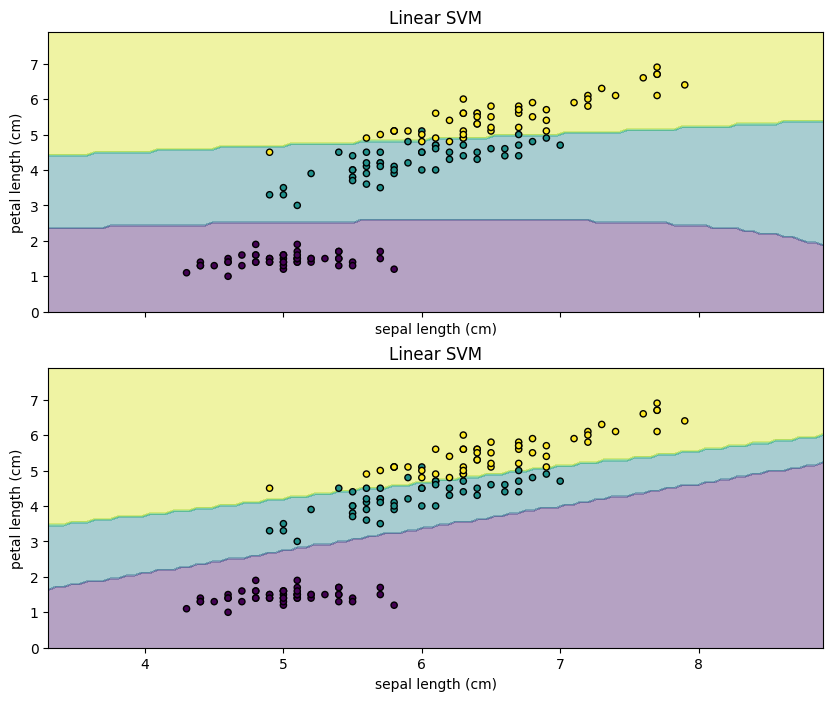

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
from itertools import product

f, ax = plt.subplots(2, 1, sharex="col", sharey="row", figsize=(10, 8))


DecisionBoundaryDisplay.from_estimator(
    sup_vector, X_ir, alpha=0.4, ax=ax[0], response_method="predict")
ax[0].scatter(X_ir.iloc[:, 0], X_ir.iloc[:, 1], c=y, s=20, edgecolor="k")
ax[0].set_title('Linear SVM')

DecisionBoundaryDisplay.from_estimator(
    sup_linear, X_ir, alpha=0.4, ax=ax[1], response_method="predict")
ax[1].scatter(X_ir.iloc[:, 0], X_ir.iloc[:, 1], c=y, s=20, edgecolor="k")
ax[1].set_title('Linear SVM')

plt.show()

# kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn.fit(X_ir, y)

KNeighborsClassifier(n_neighbors=3)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


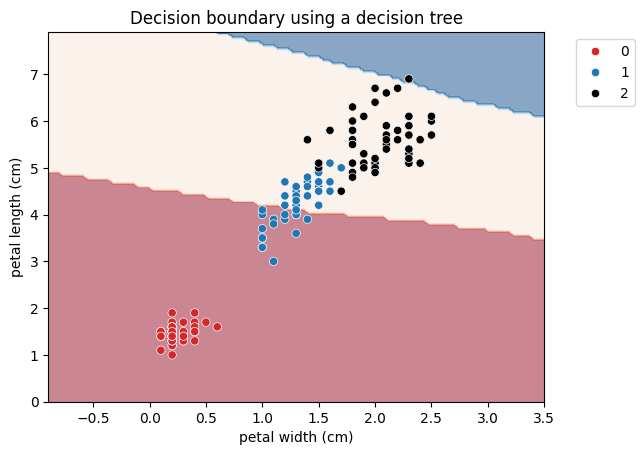

In [ ]:
palette = ["tab:red", "tab:blue", "black"]
columns = ['petal width (cm)', 'petal length (cm)']
data_all = data.copy()
data_all['target_column'] = y

DecisionBoundaryDisplay.from_estimator(
    knn, np.array(data[columns]), response_method="predict", cmap="RdBu", alpha=0.5
)
ax = sns.scatterplot(data=data_all, x=columns[0], y=columns[1],
                     hue='target_column', palette=palette)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
_ = plt.title("Decision boundary using a decision tree")